#### **Advection-Diffusion Equation**

Consider a unidimensional domain $\Omega = [0,1]$, with boundary $\partial \Omega = \Gamma_L \cup \Gamma_R$, with $\Gamma_L = \{0\}$ and $\Gamma_R = \{1\}$. Then, the problem is defined by:
$$
    \begin{cases}
        \mathrm{Pe} \, \phi_x - \phi_{xx} = 0, & (x,y)\in\Omega \\
        \phi(x) = 1, & x\in\Gamma_L \\
        \phi(x) = 0, & x\in\Gamma_R
    \end{cases}
$$

The problem described above admits an analytical solution expressed by:

$$
    \phi(x) = \frac{1 - e^{\mathrm{Pe}(x - 1)}}{1-e^{-\mathrm{Pe}}}.
$$

This solution highlights distinct transport regimes: (i) in the diffusive limit, $\mathrm{Pe}\to 0$, the field converges to $\phi(x) \to 1 - x$, corresponding to a typical linear profile of pure diffusion; and (ii) in the advective regime, $\mathrm{Pe} \gg 1$, the solution remains approximately constant at $\phi \simeq 1$ over most of the domain, adjusting abruptly to the exit boundary condition $\phi(1) = 0$ only in the neighborhood of $x = 1$.

### **1. Packages**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from typing import List, Callable, Mapping

from bernet.contracts import ISampler, Batch
from bernet.utils.statistics import lhs_1

### **2. Hyperparameters**

### **3. Implementation**

**Analytical Solution**

1. Function definition

In [ ]:
def analytical_solution(x: np.ndarray, peclet: float, tol: float = 1e-6) -> np.ndarray:
    return ( 1 - np.exp( (peclet + tol) * (x - 1) ) ) / ( 1 - np.exp(-(peclet + tol)) )

2. Ploting solution

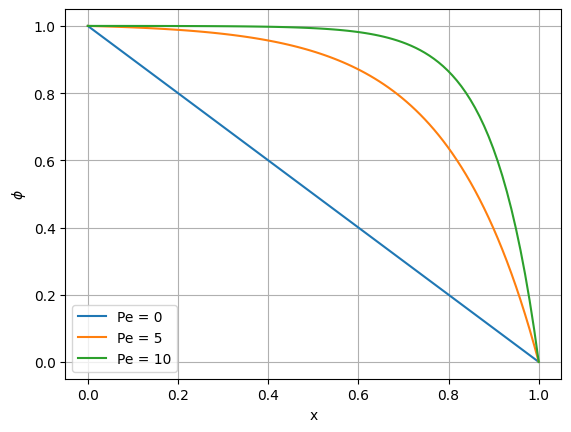

In [5]:
#-- Define the spatial domain
x = np.linspace(0, 1, 100)

#-- Compute the analytical solution
phi_Pe00 = analytical_solution(x=x, peclet=0)
phi_Pe05 = analytical_solution(x=x, peclet=5)
phi_Pe10 = analytical_solution(x=x, peclet=10)

#-- Plot the solution
plt.figure()
plt.plot(x, phi_Pe00, label="Pe = 0")
plt.plot(x, phi_Pe05, label="Pe = 5")
plt.plot(x, phi_Pe10, label="Pe = 10")
plt.xlabel("x")
plt.ylabel(r"$\phi$")
plt.legend()
plt.grid()
plt.show()

**Model**

In [ ]:
class Model(torch.nn.Module):

    def __init__(
            self,
            neurons: List[int],
            activation: torch.nn.Module,
        ) -> None:
        super(Model, self).__init__()

        #-- Define a sequential model
        self.net = torch.nn.Sequential()

        #-- Add layers
        for i in range(len(neurons) - 1):
            self.net.append(torch.nn.Linear(neurons[i], neurons[i + 1]))
            if i < len(neurons) - 2:
                self.net.append(activation)
        
        return

    def forward(
            self,
            x: torch.Tensor,
        ) -> torch.Tensor:

        #-- Forward pass
        phi = self.net(x)

        return phi

**Sampler**

In [ ]:
class Sampler(ISampler):

    def __init__(
            self,
            spacing: int,
            batch_size: int,
            ratio: float,
            func: Callable[[np.ndarray], np.ndarray],
        ) -> None:
        """
        Parameters
        ----------
        num_samples : int
            Total number of samples.
        batch_size : int
            Number of samples per batch.
        ratio : float
            Number of samples used by metrics divided by num_samples.
        func : Callable[[np.ndarray], np.ndarray]
            Solution based on input
        """
        super().__init__()

        #-- Inputs
        self._spacing = spacing
        self._batch_size = batch_size
        self._ratio = ratio
        self._func = func

        #-- Parameters
        self._train_data: List[Batch] = None
        self._metrics_data: Mapping[str, torch.Tensor] = None

        return
    
    def generate(self) -> int:
        super().generate()

        #-------------------------------------------#
        # 1. Generate random points in the domain
        #-------------------------------------------#
        #-- Number of samples
        num_samples = int(1 / self._spacing)

        #-- Generate points using latin hypercube sampling
        x_col = (1 - self._spacing) * lhs_1(n=num_samples - 2) + 0.5 * self._spacing
        x_bc = np.array([0., 1.])
                
        #-------------------------------------------#
        # 2. Split training and testing data
        #-------------------------------------------#
        #-- Compute the permutation of all sample indexes
        indexes = np.random.permutation(num_samples)

        #-- Compute the number of training samples
        n = int((1 - self._ratio) * num_samples)

        #-- Create training and testing samples
        x_train = x_col[indexes[:n]]
        x_metrics = x_col[indexes[n:]]

        #-- Evaluate function at boundary and testing points
        y_bc = self._func(x_bc)
        y_metrics = self._func(x_metrics)

        #-------------------------------------------#
        # 3. Create training and testing data
        #-------------------------------------------#
        #-- Create testing data
        metrics_data = {
            "x": torch.from_numpy(x_metrics).view(-1, 1),
            "y": torch.from_numpy(y_metrics).view(-1, 1),
        }

        #-- Create training data
        #-- Number of batches
        num_batches = int(x_train.size / self._batch_size)

        #-- Create list with batches
        train_data: List[Batch] = []

        for i in range(num_batches):
            batch = Batch(
                residual={
                    "x": torch.from_numpy(x_train[i * self._batch_size:(i + 1) * self._batch_size]).view(-1, 1),
                },
                boundary={
                    "x": torch.from_numpy(x_bc).view(-1, 1),
                    "y": torch.from_numpy(y_bc).view(-1, 1),
                },
            )
            train_data.append(batch)

        return len(self._train_data)
    
    def batch(self, index: int) -> Batch:
        super().batch(index)
        return self._train_data[index]
    
    def metrics(self) -> Mapping[str, torch.Tensor]:
        super().metrics()
        return self._metrics_data

### 4. Training

### 5. Results